In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('results.csv')

In [3]:
df.head()

,home_team,away_team,home_goals,away_goals,result,season
0,Sheffield United,Liverpool,1.0,1.0,D,2006-2007
1,Arsenal,Aston Villa,1.0,1.0,D,2006-2007
2,Everton,Watford,2.0,1.0,H,2006-2007
3,Newcastle United,Wigan Athletic,2.0,1.0,H,2006-2007
4,Portsmouth,Blackburn Rovers,3.0,0.0,H,2006-2007


In [28]:
df['season'].value_counts()

season
2006-2007    380
2007-2008    380
2008-2009    380
2009-2010    380
2010-2011    380
2011-2012    380
2012-2013    380
2013-2014    380
2014-2015    380
2015-2016    380
2016-2017    380
2017-2018    380
Name: count, dtype: int64

In [4]:
df.isna().sum()

home_team     0
away_team     0
home_goals    0
away_goals    0
result        0
season        0
dtype: int64

In [6]:
v = df[['home_goals']].value_counts()
v

home_goals
1.0           1448
2.0           1125
0.0           1057
3.0            573
4.0            234
5.0             77
6.0             30
7.0             10
8.0              5
9.0              1
Name: count, dtype: int64

<Axes: xlabel='home_goals', ylabel='Count'>

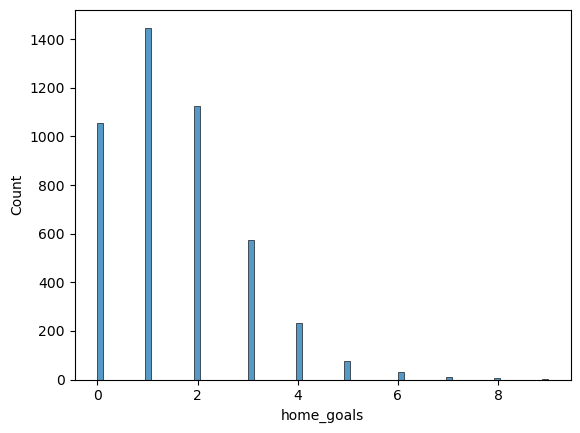

In [7]:
sns.histplot(df['home_goals'])

<Axes: xlabel='result', ylabel='count'>

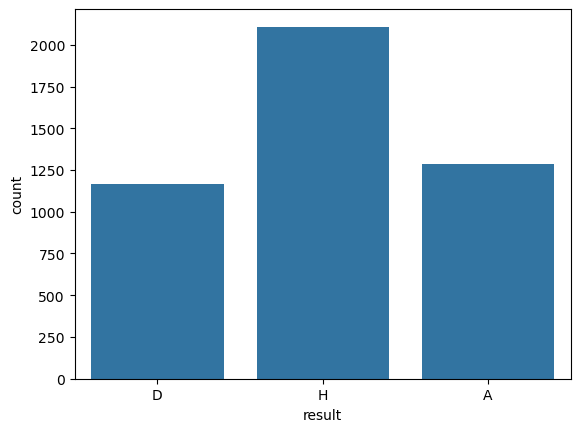

In [8]:
sns.countplot(x = df['result'])

In [9]:
df['home_team'].value_counts().head()

home_team
Arsenal              228
Everton              228
Liverpool            228
Manchester City      228
Manchester United    228
Name: count, dtype: int64

In [10]:
df.head()

,home_team,away_team,home_goals,away_goals,result,season
0,Sheffield United,Liverpool,1.0,1.0,D,2006-2007
1,Arsenal,Aston Villa,1.0,1.0,D,2006-2007
2,Everton,Watford,2.0,1.0,H,2006-2007
3,Newcastle United,Wigan Athletic,2.0,1.0,H,2006-2007
4,Portsmouth,Blackburn Rovers,3.0,0.0,H,2006-2007


In [11]:
df['total_goals'] = df['home_goals'] + df['away_goals']

In [12]:
df.head()

,home_team,away_team,home_goals,away_goals,result,season,total_goals
0,Sheffield United,Liverpool,1.0,1.0,D,2006-2007,2.0
1,Arsenal,Aston Villa,1.0,1.0,D,2006-2007,2.0
2,Everton,Watford,2.0,1.0,H,2006-2007,3.0
3,Newcastle United,Wigan Athletic,2.0,1.0,H,2006-2007,3.0
4,Portsmouth,Blackburn Rovers,3.0,0.0,H,2006-2007,3.0


In [13]:
df['total_goals'].mean()

np.float64(2.6875)

In [14]:
df['season'].value_counts()

season
2006-2007    380
2007-2008    380
2008-2009    380
2009-2010    380
2010-2011    380
2011-2012    380
2012-2013    380
2013-2014    380
2014-2015    380
2015-2016    380
2016-2017    380
2017-2018    380
Name: count, dtype: int64

In [15]:
goals_per_season = df.groupby('season')['total_goals'].mean().sort_index(ascending=False)

In [16]:
goals_per_season

season
2017-2018    2.678947
2016-2017    2.800000
2015-2016    2.700000
2014-2015    2.565789
2013-2014    2.768421
2012-2013    2.797368
2011-2012    2.805263
2010-2011    2.797368
2009-2010    2.771053
2008-2009    2.478947
2007-2008    2.636842
2006-2007    2.450000
Name: total_goals, dtype: float64

<Axes: xlabel='total_goals', ylabel='season'>

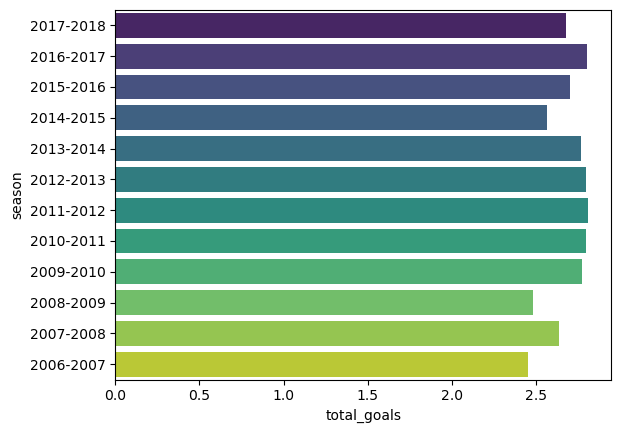

In [17]:
sns.barplot(x=goals_per_season, y=goals_per_season.index, palette='viridis')

In [18]:
df.loc[[(df['home_goals']-df['away_goals']).abs().idxmax()]]

,home_team,away_team,home_goals,away_goals,result,season,total_goals
1265,Tottenham Hotspur,Wigan Athletic,9.0,1.0,H,2009-2010,10.0


In [19]:
(df['home_goals'] - df['away_goals']).max()

8.0

In [20]:
away_wins = df[df['result'] == 'A'].groupby('away_team').size().sort_values(ascending=False).head(10)

In [21]:
df.groupby('away_team').apply(lambda x : (x['result'] == 'A').sum()).sort_values(ascending=False).head()

away_team
Chelsea              123
Manchester United    119
Arsenal              103
Manchester City      100
Liverpool             98
dtype: int64

<Axes: xlabel='None', ylabel='away_team'>

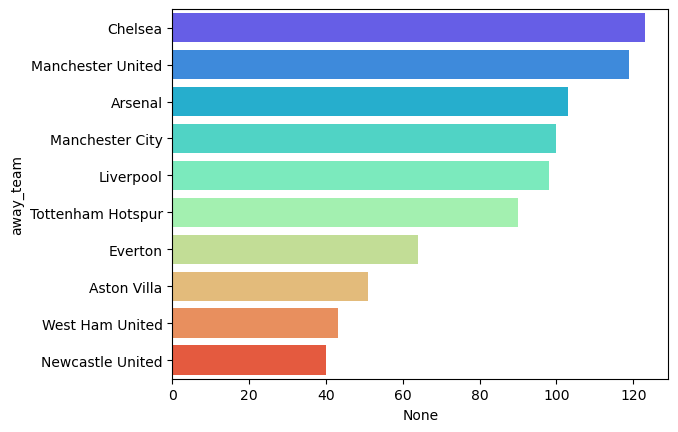

In [22]:
sns.barplot(x=away_wins,y=away_wins.index,palette='rainbow')

In [23]:
most_home_goals = df.groupby('home_team')['home_goals'].sum().sort_values(ascending=False).head(10)
most_home_goals

home_team
Manchester City      501.0
Manchester United    495.0
Chelsea              491.0
Arsenal              479.0
Liverpool            466.0
Tottenham Hotspur    422.0
Everton              395.0
West Ham United      286.0
Newcastle United     268.0
Stoke City           248.0
Name: home_goals, dtype: float64

Text(0.5, 1.0, 'Home Goals')

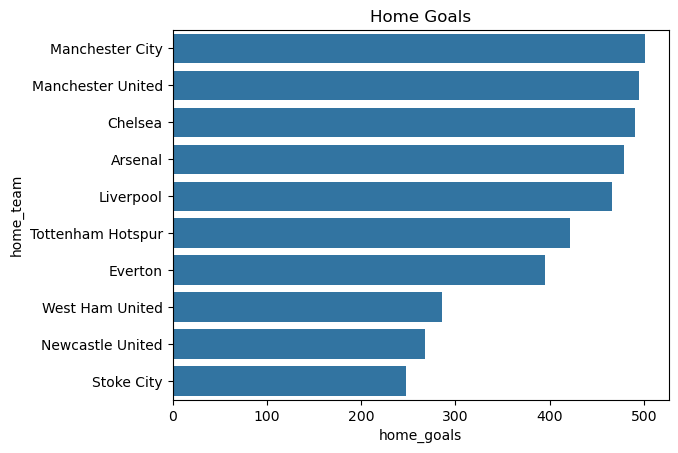

In [24]:
sns.barplot(x=most_home_goals, y=most_home_goals.index)
plt.title('Home Goals')

In [25]:
df.groupby('home_team')['away_goals'].sum().sort_values(ascending=True).head(10)

home_team
Charlton Athletic           20.0
Sheffield United            21.0
Brighton and Hove Albion    25.0
Huddersfield Town           25.0
Cardiff City                35.0
Blackpool                   37.0
Derby County                43.0
Birmingham City             58.0
Queens Park Rangers         77.0
Reading                     78.0
Name: away_goals, dtype: float64

In [26]:
most_away_goals = df.groupby('away_team')['away_goals'].sum().sort_values(ascending=False).head()
most_away_goals

away_team
Arsenal              382.0
Manchester United    372.0
Chelsea              368.0
Manchester City      365.0
Liverpool            351.0
Name: away_goals, dtype: float64

<Axes: xlabel='away_goals', ylabel='away_team'>

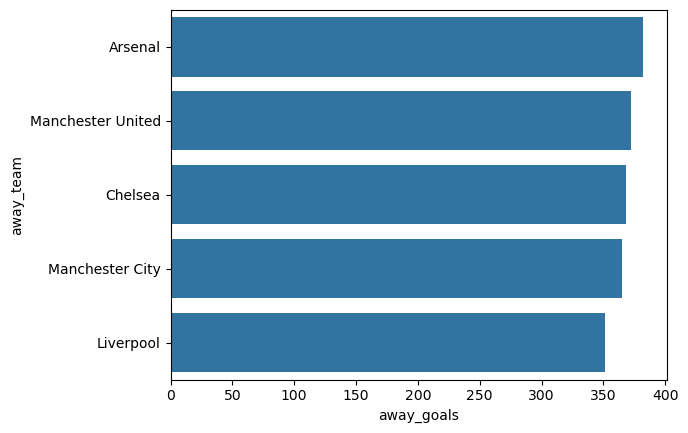

In [27]:
sns.barplot(x=most_away_goals,y=most_away_goals.index)

In [34]:
df['home_team'].value_counts().sort_values().head(10)

home_team
Huddersfield Town           19
Cardiff City                19
Brighton and Hove Albion    19
Charlton Athletic           19
Blackpool                   19
Derby County                19
Sheffield United            19
Reading                     57
Queens Park Rangers         57
Wolverhampton Wanderers     57
Name: count, dtype: int64